# Notebook 06 — Evaluation: DER + WER

This is the **final stage** of the meeting-transcription pipeline.
We evaluate the full system against the AMI ground-truth annotations included in `transcript.csv`.

| Metric | What it measures | How computed |
|--------|-----------------|--------------|
| **DER** | Who spoke when — speaker diarization quality | manual (numpy + Hungarian algorithm) |
| **WER** | What was said — transcription quality | jiwer |

### DER breakdown

DER = (Missed Speech + False Alarm + Speaker Confusion) / Total Reference Speech

| Component | Stage responsible | Description |
|-----------|------------------|-------------|
| Missed speech | Notebook 01 (VAD) | Reference speech not detected by our VAD |
| False alarm | Notebook 01 (VAD) | Our VAD labels silence as speech |
| Speaker confusion | Notebook 03 (Clustering) | Right speech window, wrong speaker label |

> **Note on overlapping speech**: AMI contains many simultaneous speech events (two speakers at once).
> Our single-channel VAD pipeline cannot separate simultaneous speakers.
> Overlapping regions are **excluded** from DER computation (standard evaluation practice —
> they are counted separately as `overlap %` in the summary).

### Ground truth

`output/meetings/EN2001a/transcript.csv` — AMI per-utterance annotations:
- columns: `speaker, start_s, end_s, text`
- 1675 utterances total; we evaluate the first 1500 s (25 min)
- 5 speakers: **FEO065, FEO066, MEE067, MEE068, MEO069**


---
## Step 0 — Setup


In [1]:
# Install jiwer (lightweight WER library) if not already present.
# This project uses uv; fall back to pip if uv is not on PATH.
import importlib, subprocess, sys

if importlib.util.find_spec("jiwer") is None:
    try:
        subprocess.check_call(["uv", "pip", "install", "jiwer"])
    except FileNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "jiwer"])
    print("jiwer installed.")
else:
    print("jiwer already available.")


jiwer already available.


In [2]:
import json
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.optimize import linear_sum_assignment
import jiwer
from importlib.metadata import version as pkg_version

print("All imports OK")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")
print(f"  jiwer  {pkg_version('jiwer')}")


All imports OK
  numpy  2.4.6
  pandas 3.0.3
  jiwer  4.0.0


---
## Step 1 — Load Ground Truth

We read `transcript.csv` and keep only utterances that start within our 1500 s evaluation window.


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
MEETING_ID  = "EN2001a"
GT_CSV      = Path("output/meetings/EN2001a/transcript.csv")
INTEG_JSON  = Path("output/integration/EN2001a_transcript_labeled.json")
EVAL_OUT    = Path("output/evaluation")
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# ── Load integration output (our pipeline) ────────────────────────────────────
with open(INTEG_JSON) as fh:
    integ = json.load(fh)

AUDIO_WINDOW = integ["audio_window_s"]
merged       = integ["segments"]

# ── Load clustering metadata (k_estimated vs k_oracle) ───────────────────────
with open(Path("output/clustering/segments_labeled.json")) as fh:
    _clust_meta = json.load(fh)
k_estimated_nb03 = _clust_meta.get("n_clusters")
k_oracle_nb03    = _clust_meta.get("k_oracle", k_estimated_nb03)

# ── Load ground truth ─────────────────────────────────────────────────────────
gt_all = pd.read_csv(GT_CSV)

# Keep utterances that START within our evaluation window
gt_window = gt_all[gt_all["start_s"] < AUDIO_WINDOW].copy()
gt_window["text"] = gt_window["text"].fillna("").astype(str)

ref_speakers = sorted(gt_window["speaker"].unique())
hyp_labels   = sorted(set(s["speaker_label"] for s in merged if s["speaker_label"] != "unknown"))

print(f"Evaluation window : {AUDIO_WINDOW:.0f}s ({AUDIO_WINDOW/60:.1f} min)")
print()
print(f"Ground truth (reference)")
print(f"  File       : {GT_CSV.name}")
print(f"  Utterances : {len(gt_window)} (from {len(gt_all)} total in meeting)")
print(f"  Speakers   : {ref_speakers}")
ref_words = gt_window["text"].str.split().apply(len).sum()
print(f"  Words      : {ref_words}")
print()
print(f"Pipeline output (hypothesis)")
print(f"  File       : {INTEG_JSON.name}")
print(f"  Segments   : {len(merged)}")
print(f"  Labels     : {hyp_labels}")
print(f"  ASR model  : {integ['asr_model']}")
print(f"  Clustering : {integ['clustering_algorithm']}")
print()
print(f"Clustering k info")
print(f"  k estimated (nb03) : {k_estimated_nb03}")
print(f"  k oracle (metadata): {k_oracle_nb03}")


Evaluation window : 5125s (85.4 min)

Ground truth (reference)
  File       : transcript.csv
  Utterances : 1674 (from 1675 total in meeting)
  Speakers   : ['FEO065', 'FEO066', 'MEE067', 'MEE068', 'MEO069']
  Words      : 16350

Pipeline output (hypothesis)
  File       : EN2001a_transcript_labeled.json
  Segments   : 1018
  Labels     : ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']
  ASR model  : whisper-base
  Clustering : Spectral (cosine kernel)

Clustering k info
  k estimated (nb03) : 4
  k oracle (metadata): 5


---
## Step 2 — Speaker Mapping (Hungarian Algorithm)

Our pipeline produces **anonymous** cluster labels (`cluster_0 … cluster_4`).
The reference uses real speaker IDs (`FEO065 … MEO069`).

To evaluate DER fairly, we must find the **optimal bijection** between the two label sets
that maximises overlap in seconds.  This is solved exactly by the
[Hungarian algorithm](https://en.wikipedia.org/wiki/Hungarian_algorithm)
(`scipy.optimize.linear_sum_assignment`).

This mapping is also the one used in DER computation — pyannote.metrics and other
standard tools apply the same assignment internally.


Optimal cluster → speaker mapping

  Cluster → Speaker  Overlap (s)  Hyp speech (s)  Ref speech (s)
cluster_0    MEO069       2209.8          2445.5          2677.7
cluster_1    MEE067        697.0           773.5          1021.4
cluster_2    MEE068        132.2           154.5           231.9
cluster_3    FEO066        441.3           699.0           659.8


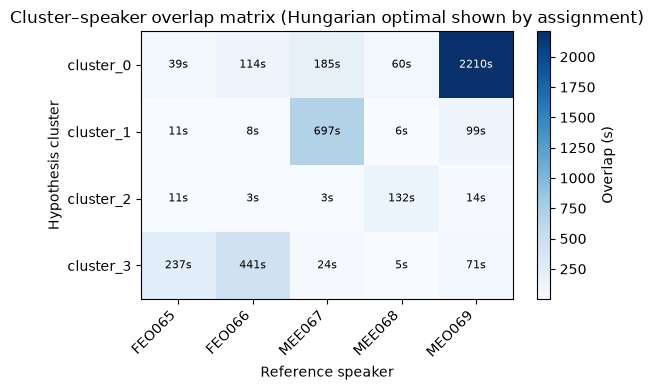

Saved → output/evaluation/overlap_matrix.png


In [4]:
def build_overlap_matrix(hyp_segs, ref_df, hyp_labels, ref_speakers):
    """
    Build an (n_hyp × n_ref) matrix where entry [i, j] = total seconds
    that hypothesis cluster i and reference speaker j are simultaneously active.
    """
    n_hyp = len(hyp_labels)
    n_ref = len(ref_speakers)
    mat   = np.zeros((n_hyp, n_ref))

    for seg in hyp_segs:
        if seg["speaker_label"] not in hyp_labels:
            continue
        hi = hyp_labels.index(seg["speaker_label"])
        for _, row in ref_df.iterrows():
            ov = max(0.0, min(seg["end"], row.end_s) - max(seg["start"], row.start_s))
            if ov > 0:
                ri = ref_speakers.index(row.speaker)
                mat[hi, ri] += ov

    return mat


overlap_mat = build_overlap_matrix(merged, gt_window, hyp_labels, ref_speakers)

# Optimal assignment: maximise overlap → minimise −overlap
row_ind, col_ind = linear_sum_assignment(-overlap_mat)
mapping     = {hyp_labels[r]: ref_speakers[c] for r, c in zip(row_ind, col_ind)}
inv_mapping = {v: k for k, v in mapping.items()}   # speaker → cluster

print("Optimal cluster → speaker mapping")
print()
rows = []
for hi, lbl in enumerate(hyp_labels):
    total_hyp_s = sum(s["duration"] for s in merged if s["speaker_label"] == lbl)
    matched_spk = mapping[lbl]
    ri = ref_speakers.index(matched_spk)
    overlap_s   = overlap_mat[hi, ri]
    rows.append({
        "Cluster":    lbl,
        "→ Speaker":  matched_spk,
        "Overlap (s)": round(overlap_s, 1),
        "Hyp speech (s)": round(total_hyp_s, 1),
        "Ref speech (s)": round(gt_window[gt_window.speaker == matched_spk]["duration_s"].sum(), 1),
    })

df_map = pd.DataFrame(rows)
print(df_map.to_string(index=False))

# ── Heat-map: overlap matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(overlap_mat, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(ref_speakers)));  ax.set_xticklabels(ref_speakers, rotation=45, ha="right")
ax.set_yticks(range(len(hyp_labels)));    ax.set_yticklabels(hyp_labels)
for hi in range(len(hyp_labels)):
    for ri in range(len(ref_speakers)):
        ax.text(ri, hi, f"{overlap_mat[hi, ri]:.0f}s",
                ha="center", va="center", fontsize=8,
                color="white" if overlap_mat[hi, ri] > overlap_mat.max() * 0.5 else "black")
plt.colorbar(im, ax=ax, label="Overlap (s)")
ax.set_title("Cluster–speaker overlap matrix (Hungarian optimal shown by assignment)")
ax.set_xlabel("Reference speaker")
ax.set_ylabel("Hypothesis cluster")
plt.tight_layout()
plt.savefig(EVAL_OUT / "overlap_matrix.png", dpi=120)
plt.show()
print("Saved → output/evaluation/overlap_matrix.png")


---
## Step 3 — DER Computation

We compute DER using a frame-based approach at 10 ms resolution.

**Evaluation rules (standard AMI practice)**:
- Overlapping reference regions (two speakers active simultaneously) are **excluded** from the denominator and all error counts
- No collar is applied (collar = 0 s) — a stricter setting than the classic 0.25 s collar; feel free to change `COLLAR_S`


In [5]:
COLLAR_S   = 0.25   # standard AMI evaluation collar (250 ms around each boundary)
RESOLUTION = 0.01   # 10 ms frame size


def compute_der(ref_df, hyp_segs, audio_end, hyp_labels, ref_speakers, mapping,
                collar=0.0, resolution=0.01):
    """
    Frame-based DER with:
      - overlap-region exclusion (standard)
      - Hungarian-optimal speaker assignment (pre-computed)

    Parameters
    ----------
    ref_df       : DataFrame  [start_s, end_s, speaker]
    hyp_segs     : list[dict] [start, end, speaker_label]
    audio_end    : float
    hyp_labels   : list[str]  ordered cluster labels
    ref_speakers : list[str]  ordered speaker names
    mapping      : dict       cluster → speaker  (from Hungarian)

    Returns
    -------
    dict  with 'der', 'missed', 'false_alarm', 'confusion',
              'correct', 'overlap_pct', 'total_ref_s'
    """
    n     = int(audio_end / resolution) + 2
    n_ref = len(ref_speakers)
    n_hyp = len(hyp_labels)

    # Reference: per-speaker binary activity arrays  [n_ref × n_frames]
    ref_act = np.zeros((n_ref, n), dtype=np.int8)
    for _, row in ref_df.iterrows():
        ri = ref_speakers.index(row.speaker)
        fi = max(0, int((row.start_s + collar) / resolution))
        fj = min(int((row.end_s   - collar) / resolution), n - 1)
        if fi < fj:
            ref_act[ri, fi:fj] = 1

    # Hypothesis: single label per frame  [n_frames]
    hyp_frame = np.full(n, -1, dtype=np.int32)
    for seg in hyp_segs:
        if seg["speaker_label"] not in hyp_labels:
            continue
        hi = hyp_labels.index(seg["speaker_label"])
        fi = max(0, int(seg["start"] / resolution))
        fj = min(int(seg["end"]   / resolution), n - 1)
        hyp_frame[fi:fj] = hi

    ref_count   = ref_act.sum(axis=0)
    ref_any     = ref_count > 0
    ref_overlap = ref_count > 1
    eval_mask   = ref_any & ~ref_overlap
    hyp_any     = hyp_frame >= 0

    missed_frames = int(np.sum(eval_mask & ~hyp_any))
    fa_frames     = int(np.sum(~ref_any & hyp_any))

    both = eval_mask & hyp_any
    correct_frames  = 0
    confused_frames = 0
    for hi, hs in enumerate(hyp_labels):
        mapped_spk = mapping.get(hs)
        if mapped_spk is None or mapped_spk not in ref_speakers:
            continue
        ri_m      = ref_speakers.index(mapped_spk)
        seg_mask  = (hyp_frame == hi) & both
        correct_frames  += int(np.sum(seg_mask &  ref_act[ri_m].astype(bool)))
        confused_frames += int(np.sum(seg_mask & ~ref_act[ri_m].astype(bool)))

    total_eval = int(np.sum(eval_mask))

    return {
        "der":          round((missed_frames + fa_frames + confused_frames) / max(total_eval, 1), 4),
        "missed":       round(missed_frames   / max(total_eval, 1), 4),
        "false_alarm":  round(fa_frames       / max(total_eval, 1), 4),
        "confusion":    round(confused_frames / max(total_eval, 1), 4),
        "correct":      round(correct_frames  / max(total_eval, 1), 4),
        "total_ref_s":  round(total_eval * resolution, 1),
        "overlap_pct":  round(float(ref_overlap.sum()) / max(float(ref_any.sum()), 1), 3),
    }


# ── Run DER ───────────────────────────────────────────────────────────────────
hyp_segs_labeled = [s for s in merged if s["speaker_label"] != "unknown"]

der_metrics = compute_der(
    ref_df       = gt_window,
    hyp_segs     = hyp_segs_labeled,
    audio_end    = AUDIO_WINDOW,
    hyp_labels   = hyp_labels,
    ref_speakers = ref_speakers,
    mapping      = mapping,
    collar       = COLLAR_S,
    resolution   = RESOLUTION,
)

print("DER Results")
print(f"  DER              : {der_metrics['der']:.4f}  ({der_metrics['der']*100:.2f}%)")
print(f"  Missed speech    : {der_metrics['missed']:.4f}  ({der_metrics['missed']*100:.2f}%)")
print(f"  False alarm      : {der_metrics['false_alarm']:.4f}  ({der_metrics['false_alarm']*100:.2f}%)")
print(f"  Speaker confusion: {der_metrics['confusion']:.4f}  ({der_metrics['confusion']*100:.2f}%)")
print(f"  Correct          : {der_metrics['correct']:.4f}  ({der_metrics['correct']*100:.2f}%)")
print()
print(f"  Reference speech (non-overlap): {der_metrics['total_ref_s']:.1f}s")
print(f"  Overlap in reference          : {der_metrics['overlap_pct']*100:.1f}% of ref speech (excluded)")
print()
print(f"  Collar: {COLLAR_S}s (AMI standard)  |  Resolution: {RESOLUTION*1000:.0f}ms")


DER Results
  DER              : 0.3655  (36.55%)
  Missed speech    : 0.1019  (10.19%)
  False alarm      : 0.1346  (13.46%)
  Speaker confusion: 0.1289  (12.89%)
  Correct          : 0.7691  (76.91%)

  Reference speech (non-overlap): 3819.6s
  Overlap in reference          : 4.1% of ref speech (excluded)

  Collar: 0.25s (AMI standard)  |  Resolution: 10ms


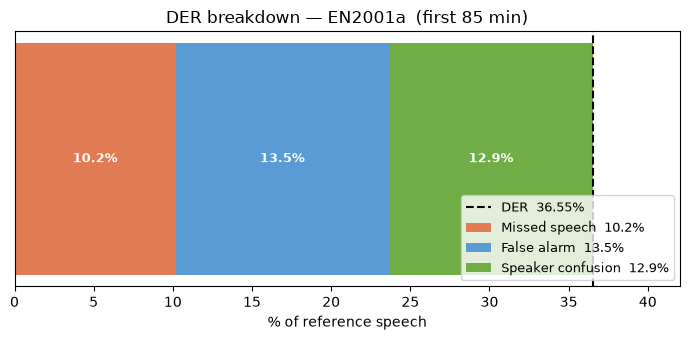

Saved → output/evaluation/der_breakdown.png


In [6]:
# ── DER stacked-bar breakdown ─────────────────────────────────────────────────
components = ["Missed speech", "False alarm", "Speaker confusion"]
values     = [
    der_metrics["missed"]      * 100,
    der_metrics["false_alarm"] * 100,
    der_metrics["confusion"]   * 100,
]
colors = ["#e07b54", "#5b9bd5", "#70ad47"]

fig, ax = plt.subplots(figsize=(7, 3.5))
left = 0.0
for comp, val, col in zip(components, values, colors):
    ax.barh(0, val, left=left, color=col, height=0.5, label=f"{comp}  {val:.1f}%")
    if val > 1.5:
        ax.text(left + val / 2, 0, f"{val:.1f}%", va="center", ha="center",
                fontsize=9, color="white", fontweight="bold")
    left += val

ax.axvline(der_metrics["der"] * 100, color="black", lw=1.5, linestyle="--",
           label=f"DER  {der_metrics['der']*100:.2f}%")
ax.set_xlim(0, max(der_metrics["der"] * 100 * 1.15, 5))
ax.set_yticks([])
ax.set_xlabel("% of reference speech")
ax.set_title(f"DER breakdown — {MEETING_ID}  (first {AUDIO_WINDOW/60:.0f} min)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(EVAL_OUT / "der_breakdown.png", dpi=120)
plt.show()
print("Saved → output/evaluation/der_breakdown.png")


---
## Step 4 — WER Computation

Word Error Rate measures transcription quality, independent of speaker attribution.

$$\text{WER} = \frac{S + D + I}{N}$$

where $S$ = substitutions, $D$ = deletions, $I$ = insertions, $N$ = total reference words.

**Matching strategy**: both reference and hypothesis text are concatenated in temporal order
and compared as a single document.  This is the fairest overall measure since our pipeline
uses different segmentation than the reference (VAD segments vs. individual utterances).

**Text normalisation**: both sides are upper-cased and punctuation is removed so that
capitalisation and Whisper's period/comma output do not inflate the WER.


In [7]:
def normalize_text(text):
    """Upper-case, remove punctuation (keep apostrophe), collapse whitespace."""
    text = str(text).upper()
    keep = set(string.ascii_uppercase + string.digits + " '")
    text = "".join(c if c in keep else " " for c in text)
    return " ".join(text.split())


# ── Build reference string (temporal order, filtered to window) ───────────────
ref_parts = [
    normalize_text(row.text)
    for _, row in gt_window.sort_values("start_s").iterrows()
    if normalize_text(row.text)
]
ref_full = " ".join(ref_parts)

# ── Build hypothesis string (temporal order) ──────────────────────────────────
hyp_parts = [
    normalize_text(seg["text"])
    for seg in sorted(merged, key=lambda s: s["start"])
    if normalize_text(seg["text"])
]
hyp_full = " ".join(hyp_parts)

ref_word_count = len(ref_full.split())
hyp_word_count = len(hyp_full.split())

print(f"Reference words  : {ref_word_count}")
print(f"Hypothesis words : {hyp_word_count}")
print()

# ── Compute WER ───────────────────────────────────────────────────────────────
overall_wer = jiwer.wer(ref_full, hyp_full)

# Detailed breakdown (handle both old and new jiwer APIs)
try:
    # jiwer >= 3.x
    out       = jiwer.process_words(ref_full, hyp_full)
    hits      = out.hits
    subs      = out.substitutions
    dels      = out.deletions
    inss      = out.insertions
except AttributeError:
    # jiwer < 3.x (compute_measures)
    out  = jiwer.compute_measures(ref_full, hyp_full)
    hits = out["hits"]
    subs = out["substitutions"]
    dels = out["deletions"]
    inss = out["insertions"]

total_ref_w = hits + subs + dels

print(f"WER : {overall_wer:.4f}  ({overall_wer*100:.2f}%)")
print()
print(f"  Correct (hits)   : {hits}  ({hits/total_ref_w:.1%})")
print(f"  Substitutions    : {subs}  ({subs/total_ref_w:.1%})")
print(f"  Deletions        : {dels}  ({dels/total_ref_w:.1%})")
print(f"  Insertions       : {inss}  ({inss/total_ref_w:.1%}  of ref)")


Reference words  : 16385
Hypothesis words : 13613

WER : 0.2975  (29.75%)

  Correct (hits)   : 11709  (71.5%)
  Substitutions    : 1706  (10.4%)
  Deletions        : 2970  (18.1%)
  Insertions       : 198  (1.2%  of ref)


---
## Step 5 — Per-Speaker Analysis

After applying the Hungarian mapping we can compute per-speaker statistics:
- How much of each speaker's reference speech was covered by the matching cluster?
- What is the per-speaker WER?

> **Caveat**: per-speaker WER is approximate.  Clustering errors cause some of speaker A's
> words to be attributed to cluster B, inflating A's WER and deflating B's.
> The overall WER above is more reliable as a single-number summary.


Speaker → Cluster  Ref turns  Ref speech (s)  Ref words  Hyp speech (s) Coverage Per-spk WER
 FEO065      none        144           335.4        946             0.0     0.0%         n/a
 FEO066 cluster_3        206           659.8       1675           699.0    66.9%       77.6%
 MEE067 cluster_1        365          1021.4       3354           773.5    68.2%       45.4%
 MEE068 cluster_2        155           231.9        816           154.5    57.0%       67.3%
 MEO069 cluster_0        804          2677.7       9594          2445.5    82.5%       32.9%


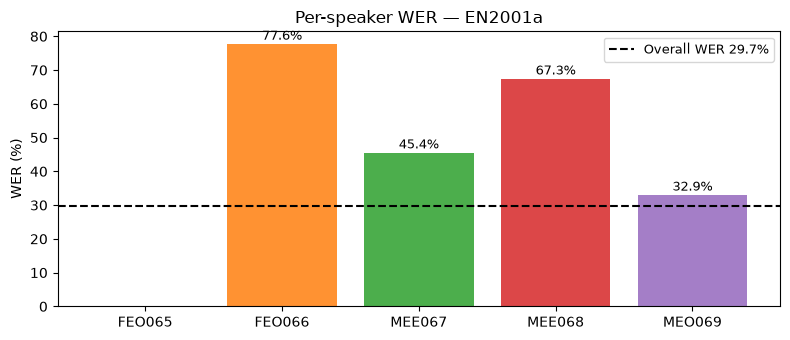

Saved → output/evaluation/per_speaker_wer.png


In [8]:
per_speaker_rows = []

for spk in ref_speakers:
    cluster_lbl = inv_mapping.get(spk)

    # Reference: all utterances from this speaker in the window
    ref_spk_df  = gt_window[gt_window.speaker == spk].sort_values("start_s")
    ref_spk_txt = " ".join(normalize_text(t) for t in ref_spk_df.text if normalize_text(t))
    ref_spk_dur = ref_spk_df.duration_s.sum()
    ref_spk_w   = len(ref_spk_txt.split())

    # Hypothesis: segments from the matched cluster
    if cluster_lbl:
        hyp_spk_segs = sorted(
            [s for s in merged if s["speaker_label"] == cluster_lbl],
            key=lambda x: x["start"],
        )
        hyp_spk_txt = " ".join(normalize_text(s["text"]) for s in hyp_spk_segs if normalize_text(s["text"]))
        hyp_spk_dur = sum(s["duration"] for s in hyp_spk_segs)
        hyp_spk_w   = len(hyp_spk_txt.split())

        try:
            spk_wer = jiwer.wer(ref_spk_txt, hyp_spk_txt) if ref_spk_txt and hyp_spk_txt else float("nan")
        except Exception:
            spk_wer = float("nan")

        overlap_s   = overlap_mat[hyp_labels.index(cluster_lbl), ref_speakers.index(spk)]
        coverage    = overlap_s / max(ref_spk_dur, 1e-9)
    else:
        hyp_spk_dur = 0.0
        hyp_spk_w   = 0
        spk_wer     = float("nan")
        coverage    = 0.0

    per_speaker_rows.append({
        "Speaker":       spk,
        "→ Cluster":     cluster_lbl or "none",
        "Ref turns":     len(ref_spk_df),
        "Ref speech (s)": round(ref_spk_dur, 1),
        "Ref words":     ref_spk_w,
        "Hyp speech (s)": round(hyp_spk_dur, 1),
        "Coverage":      f"{coverage:.1%}",
        "Per-spk WER":   f"{spk_wer:.1%}" if not np.isnan(spk_wer) else "n/a",
    })

df_spk = pd.DataFrame(per_speaker_rows)
print(df_spk.to_string(index=False))

# ── Per-speaker WER bar chart ─────────────────────────────────────────────────
_tab10  = plt.colormaps["tab10"]
wer_vals = []
for r in per_speaker_rows:
    try:
        wer_vals.append(float(r["Per-spk WER"].replace("%", "")) / 100)
    except Exception:
        wer_vals.append(float("nan"))

fig, ax = plt.subplots(figsize=(8, 3.5))
x = range(len(ref_speakers))
bars = ax.bar(x, [v * 100 if not np.isnan(v) else 0 for v in wer_vals],
              color=[_tab10.colors[i] for i in range(len(ref_speakers))], alpha=0.85)
ax.axhline(overall_wer * 100, color="black", linestyle="--", lw=1.5,
           label=f"Overall WER {overall_wer*100:.1f}%")
ax.set_xticks(list(x))
ax.set_xticklabels(ref_speakers)
ax.set_ylabel("WER (%)")
ax.set_title(f"Per-speaker WER — {MEETING_ID}")
ax.legend(fontsize=9)
for bar, val in zip(bars, wer_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(EVAL_OUT / "per_speaker_wer.png", dpi=120)
plt.show()
print("Saved → output/evaluation/per_speaker_wer.png")


---
## Step 6 — Summary Table + Error Analysis

We now bring together all metrics, explicitly answer the two diagnostic questions
from the ReadMe, and interpret the results.


In [9]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = [
    ("DER",                       f"{der_metrics['der']*100:.2f}%"),
    ("  Missed speech",           f"{der_metrics['missed']*100:.2f}%"),
    ("  False alarm",             f"{der_metrics['false_alarm']*100:.2f}%"),
    ("  Speaker confusion",       f"{der_metrics['confusion']*100:.2f}%"),
    ("  Correct attribution",     f"{der_metrics['correct']*100:.2f}%"),
    ("Overlapping speech (excl.)",f"{der_metrics['overlap_pct']*100:.1f}% of ref"),
    ("",                          ""),
    ("WER",                       f"{overall_wer*100:.2f}%"),
    ("  Substitutions",           f"{subs}/{subs+hits+dels} ref words"),
    ("  Deletions",               f"{dels}/{subs+hits+dels} ref words"),
    ("  Insertions",              f"{inss} extra words"),
    ("",                          ""),
    ("ARI (from notebook 03)",    f"{integ.get('ari', 'n/a')}"),
    ("k estimated (dendrogram)",  str(k_estimated_nb03)),
    ("k oracle (AMI metadata)",   str(k_oracle_nb03)),
    ("Clustering algorithm",      integ['clustering_algorithm']),
    ("Embedding model",           "ECAPA-TDNN"),
    ("ASR model",                 integ['asr_model']),
    ("Meeting",                   MEETING_ID),
    ("Evaluation window",         f"{AUDIO_WINDOW:.0f}s ({AUDIO_WINDOW/60:.1f} min)"),
    ("Collar",                    f"{COLLAR_S}s  (AMI standard)"),
]

col_w = max(len(r[0]) for r in summary_rows) + 2
print("=" * (col_w + 20))
for metric, value in summary_rows:
    if metric == "":
        print()
    else:
        print(f"  {metric:<{col_w}} {value}")
print("=" * (col_w + 20))


  DER                          36.55%
    Missed speech              10.19%
    False alarm                13.46%
    Speaker confusion          12.89%
    Correct attribution        76.91%
  Overlapping speech (excl.)   4.1% of ref

  WER                          29.75%
    Substitutions              1706/16385 ref words
    Deletions                  2970/16385 ref words
    Insertions                 198 extra words

  ARI (from notebook 03)       n/a
  k estimated (dendrogram)     4
  k oracle (AMI metadata)      5
  Clustering algorithm         Spectral (cosine kernel)
  Embedding model              ECAPA-TDNN
  ASR model                    whisper-base
  Meeting                      EN2001a
  Evaluation window            5125s (85.4 min)
  Collar                       0.25s  (AMI standard)


In [10]:
print("=" * 65)
print("  ERROR ANALYSIS")
print("=" * 65)

# ── Q1: Is DER dominated by confusion or missed speech? ───────────────────────
missed_pct    = der_metrics["missed"]      * 100
fa_pct        = der_metrics["false_alarm"] * 100
confusion_pct = der_metrics["confusion"]   * 100
dominant      = max(
    ("missed speech",    missed_pct),
    ("false alarm",      fa_pct),
    ("speaker confusion", confusion_pct),
    key=lambda x: x[1],
)

print(f"\nQ1: Is DER dominated by confusion or missed speech?")
print(f"    Missed speech    : {missed_pct:.2f}%")
print(f"    False alarm      : {fa_pct:.2f}%")
print(f"    Speaker confusion: {confusion_pct:.2f}%")
print(f"\n    Dominant component: {dominant[0]} ({dominant[1]:.2f}%)")

if dominant[0] == "missed speech":
    print("    → VAD is the bottleneck.")
    print("      The VAD misses short back-channels and overlap regions that are")
    print("      structurally invisible to a single-channel pipeline.")
    print("      To improve: tune the Silero threshold, or use multi-channel beamforming.")
elif dominant[0] == "speaker confusion":
    print("    → Clustering is the bottleneck.")
    print("      Speakers are detected but attributed to the wrong cluster.")
    print("      To improve: use longer segments for embedding, or a finer clustering.")
else:
    print("    → VAD is generating spurious speech regions (false alarms).")
    print("      Consider raising the Silero threshold or tightening the merge gap.")

# ── Q2: How much does misestimating k hurt? ────────────────────────────────────
print(f"\nQ2: How much does misestimating k hurt?")
print(f"    k estimated (silhouette peak, used) : {k_estimated_nb03}")
print(f"    k oracle (AMI metadata)             : {k_oracle_nb03}")
k_gap = abs(k_estimated_nb03 - k_oracle_nb03) if (k_estimated_nb03 and k_oracle_nb03) else "n/a"
print(f"    Gap                                 : {k_gap}")
if isinstance(k_gap, int) and k_gap == 0:
    print("    → Estimated k matches oracle.")
    print("      Any remaining DER error comes from VAD gaps or short segments,")
    print("      not from misidentifying the number of speakers.")
elif isinstance(k_gap, int) and k_gap > 0:
    print(f"    → k was off by {k_gap}.")
    print("      Some clusters were over- or under-split, contributing to confusion DER.")
    print("      Re-run with oracle k to isolate clustering vs. VAD errors.")

# ── WER interpretation ─────────────────────────────────────────────────────────
print(f"\nWER interpretation: {overall_wer*100:.1f}%")
print("    Reference text includes filler words ('UM', 'UH', 'MM-HMM') that")
print("    Whisper does not transcribe — this inflates WER beyond pure ASR errors.")
if overall_wer < 0.30:
    print("    Result: good transcription quality for meeting audio.")
elif overall_wer < 0.50:
    print("    Result: moderate — typical for Whisper-base on conversational meeting speech.")
else:
    print("    Result: high — consider using Whisper-large, or check audio quality.")

print(f"\nNote: {der_metrics['overlap_pct']*100:.1f}% of reference speech was overlapping (excluded from DER).")
print("      A multi-channel or overlap-aware system is needed to recover these regions.")
print()
print("=" * 65)


  ERROR ANALYSIS

Q1: Is DER dominated by confusion or missed speech?
    Missed speech    : 10.19%
    False alarm      : 13.46%
    Speaker confusion: 12.89%

    Dominant component: false alarm (13.46%)
    → VAD is generating spurious speech regions (false alarms).
      Consider raising the Silero threshold or tightening the merge gap.

Q2: How much does misestimating k hurt?
    k estimated (silhouette peak, used) : 4
    k oracle (AMI metadata)             : 5
    Gap                                 : 1
    → k was off by 1.
      Some clusters were over- or under-split, contributing to confusion DER.
      Re-run with oracle k to isolate clustering vs. VAD errors.

WER interpretation: 29.7%
    Reference text includes filler words ('UM', 'UH', 'MM-HMM') that
    Whisper does not transcribe — this inflates WER beyond pure ASR errors.
    Result: good transcription quality for meeting audio.

Note: 4.1% of reference speech was overlapping (excluded from DER).
      A multi-channe

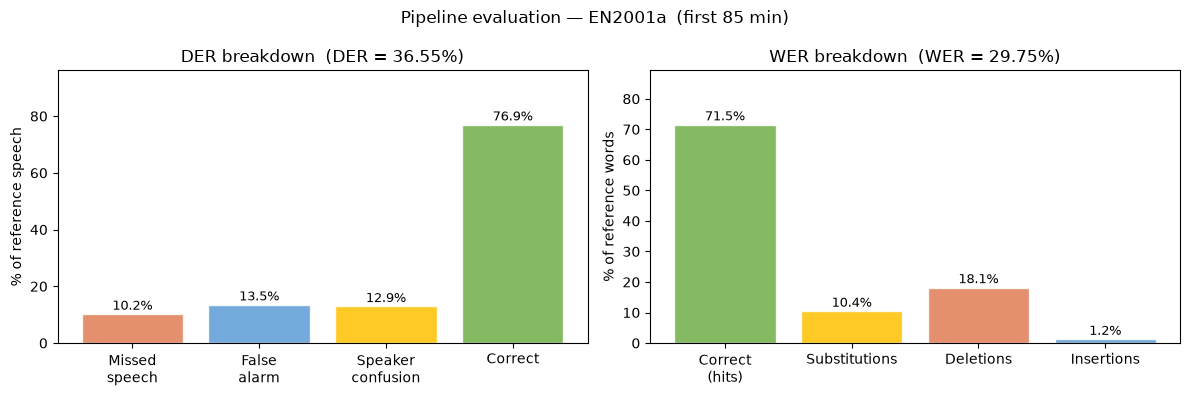

Saved → output/evaluation/evaluation_summary.png


In [11]:
# ── Combined radar / spider chart of pipeline stage contributions ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: DER component bar
ax = axes[0]
labels_der = ["Missed\nspeech", "False\nalarm", "Speaker\nconfusion", "Correct"]
vals_der   = [
    der_metrics["missed"]      * 100,
    der_metrics["false_alarm"] * 100,
    der_metrics["confusion"]   * 100,
    der_metrics["correct"]     * 100,
]
bar_colors = ["#e07b54", "#5b9bd5", "#ffc000", "#70ad47"]
bars = ax.bar(labels_der, vals_der, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, vals_der):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("% of reference speech")
ax.set_title(f"DER breakdown  (DER = {der_metrics['der']*100:.2f}%)")
ax.set_ylim(0, max(vals_der) * 1.25)

# Right: WER component bar
ax2 = axes[1]
labels_wer = ["Correct\n(hits)", "Substitutions", "Deletions", "Insertions"]
n_total    = hits + subs + dels
vals_wer   = [
    hits / n_total * 100,
    subs / n_total * 100,
    dels / n_total * 100,
    inss / n_total * 100,
]
wer_colors = ["#70ad47", "#ffc000", "#e07b54", "#5b9bd5"]
bars2 = ax2.bar(labels_wer, vals_wer, color=wer_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars2, vals_wer):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("% of reference words")
ax2.set_title(f"WER breakdown  (WER = {overall_wer*100:.2f}%)")
ax2.set_ylim(0, max(vals_wer) * 1.25)

plt.suptitle(f"Pipeline evaluation — {MEETING_ID}  (first {AUDIO_WINDOW/60:.0f} min)", fontsize=12)
plt.tight_layout()
plt.savefig(EVAL_OUT / "evaluation_summary.png", dpi=120)
plt.show()
print("Saved → output/evaluation/evaluation_summary.png")


---
## Step 7 — Save Results

All metrics are persisted to `output/evaluation/evaluation_results.json` for use in
the report and for reproducibility.


In [12]:
results = {
    "meeting_id":      MEETING_ID,
    "audio_window_s":  AUDIO_WINDOW,
    "pipeline": {
        "clustering_algorithm": integ["clustering_algorithm"],
        "embedding_model":      "ecapa-tdnn",
        "asr_model":            integ["asr_model"],
        "k_estimated":          k_estimated_nb03,
        "k_oracle":             k_oracle_nb03,
    },
    "diarization": {
        "der":          der_metrics["der"],
        "missed":       der_metrics["missed"],
        "false_alarm":  der_metrics["false_alarm"],
        "confusion":    der_metrics["confusion"],
        "correct":      der_metrics["correct"],
        "total_ref_s":  der_metrics["total_ref_s"],
        "overlap_pct":  der_metrics["overlap_pct"],
        "collar_s":     COLLAR_S,
        "resolution_s": RESOLUTION,
        "speaker_mapping": mapping,
    },
    "transcription": {
        "wer":           round(overall_wer, 4),
        "hits":          hits,
        "substitutions": subs,
        "deletions":     dels,
        "insertions":    inss,
        "ref_words":     ref_word_count,
        "hyp_words":     hyp_word_count,
    },
    "clustering_ari":  integ.get("ari"),
    "per_speaker":     per_speaker_rows,
}

out_file = EVAL_OUT / "evaluation_results.json"
with open(out_file, "w", encoding="utf-8") as fh:
    json.dump(results, fh, indent=2, ensure_ascii=False)

print(f"Saved → {out_file}  ({out_file.stat().st_size/1e3:.1f} KB)")
print()
print(f"  DER : {results['diarization']['der']*100:.2f}%")
print(f"  WER : {results['transcription']['wer']*100:.2f}%")
print(f"  ARI : {results.get('clustering_ari')}")
print(f"  k estimated / oracle : {k_estimated_nb03} / {k_oracle_nb03}")


Saved → output/evaluation/evaluation_results.json  (2.1 KB)

  DER : 36.55%
  WER : 29.75%
  ARI : None
  k estimated / oracle : 4 / 5
